<a href="https://colab.research.google.com/github/asha-92ddsmlp/Google-Colab-for-Data-Science-AI-using-Python/blob/main/Property_Price_Estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [ ]:
house = pd.read_csv('/content/drive/My Drive/Colab Notebooks/house_price_data.csv')

house.head()

,HouseID,Location,Area_sqft,Bedrooms,Bathrooms,HouseAge_years,Garage,GardenArea_sqft,DistanceToCity_km,Price_Lakh
0,3001,Chittagong,1422,3,4,20,1,1783.0,33.9,122.9
1,3002,Dhaka,3796,5,3,13,1,1410.8,13.2,499.8
2,3003,Sylhet,1010,5,1,9,1,0.0,7.8,99.6
3,3004,Rajshahi,2413,4,1,3,0,NaN,31.0,119.1
4,3005,Sylhet,2256,2,2,9,1,0.0,16.9,137.5


In [ ]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   HouseID            600 non-null    int64  
 1   Location           600 non-null    object 
 2   Area_sqft          600 non-null    int64  
 3   Bedrooms           600 non-null    int64  
 4   Bathrooms          600 non-null    int64  
 5   HouseAge_years     600 non-null    int64  
 6   Garage             600 non-null    int64  
 7   GardenArea_sqft    570 non-null    float64
 8   DistanceToCity_km  576 non-null    float64
 9   Price_Lakh         600 non-null    float64
dtypes: float64(3), int64(6), object(1)
memory usage: 47.0+ KB


In [ ]:
house.describe()

,HouseID,Area_sqft,Bedrooms,Bathrooms,HouseAge_years,Garage,GardenArea_sqft,DistanceToCity_km,Price_Lakh
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,570.000000,576.000000,600.000000
mean,3300.500000,2396.660000,3.955000,2.603333,20.325000,0.461667,617.800526,17.197569,200.593333
std,173.349358,1200.116429,1.943176,1.372028,12.123159,0.498944,656.920002,10.058313,116.016162
min,3001.000000,403.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.500000,15.000000
25%,3150.750000,1357.000000,2.000000,1.000000,9.000000,0.000000,0.000000,8.375000,117.725000
50%,3300.500000,2372.500000,4.000000,2.000000,21.000000,0.000000,424.050000,16.800000,182.900000
75%,3450.250000,3460.500000,6.000000,4.000000,31.000000,1.000000,1175.125000,25.725000,262.750000
max,3600.000000,4485.000000,7.000000,5.000000,40.000000,1.000000,1994.900000,34.900000,636.600000


In [ ]:
house.isnull().sum()

,0
HouseID,0
Location,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
HouseAge_years,0
Garage,0
GardenArea_sqft,30
DistanceToCity_km,24
Price_Lakh,0


In [ ]:
house['GardenArea_sqft'] = house['GardenArea_sqft'].fillna(

house['GardenArea_sqft'].median()
)
house['DistanceToCity_km']=house['DistanceToCity_km'].fillna(

house['DistanceToCity_km'].median ()
)

In [ ]:
house.isnull().sum()

,0
HouseID,0
Location,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
HouseAge_years,0
Garage,0
GardenArea_sqft,0
DistanceToCity_km,0
Price_Lakh,0


In [ ]:
house = house.drop('HouseID', axis=1, errors='ignore')

In [ ]:
house.columns

Index(['Location', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'HouseAge_years',
       'Garage', 'GardenArea_sqft', 'DistanceToCity_km', 'Price_Lakh'],
      dtype='object')

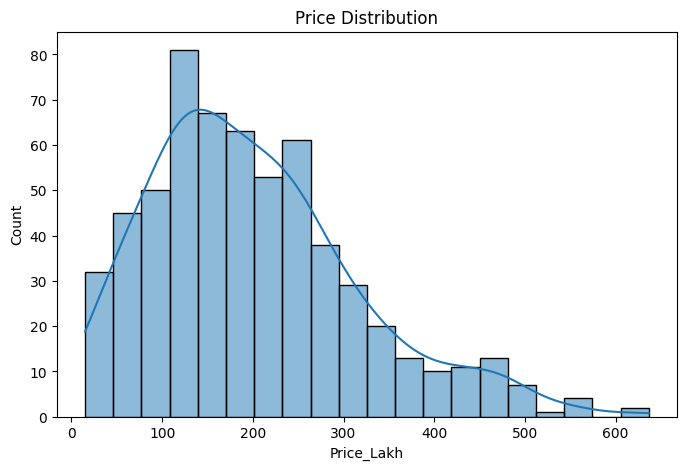

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(house['Price_Lakh'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

Most houses are concentrated around the average price range.

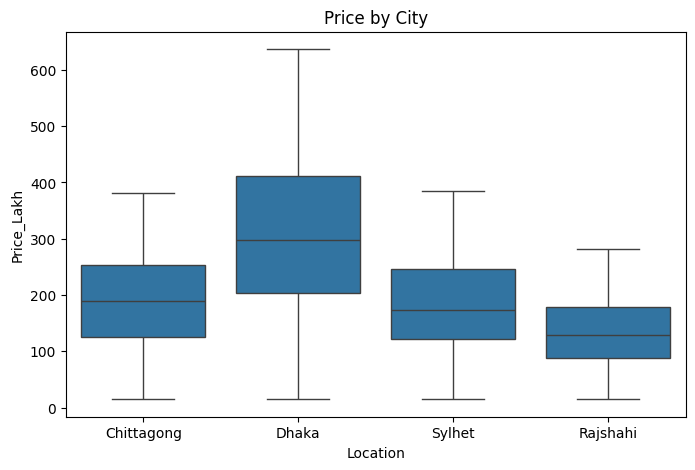

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Location',
            y='Price_Lakh',
            data=house)

plt.title("Price by City")
plt.show()

Dhaka houses are expected to have higher prices than other cities.

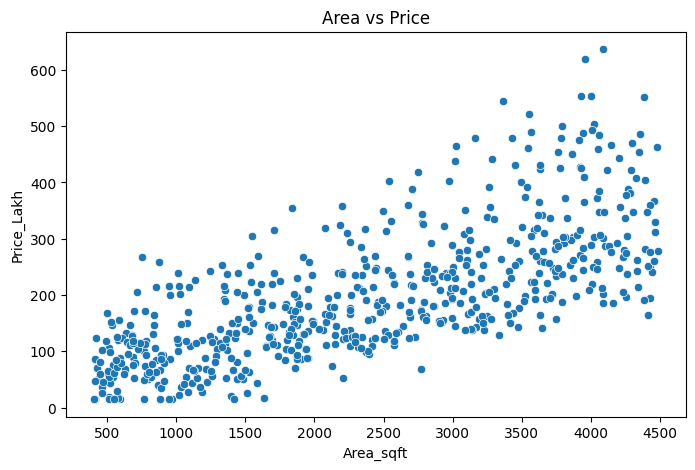

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Area_sqft',
    y='Price_Lakh',
    data=house
)
plt.title("Area vs Price")
plt.show()

As area increases, house price generally increases.

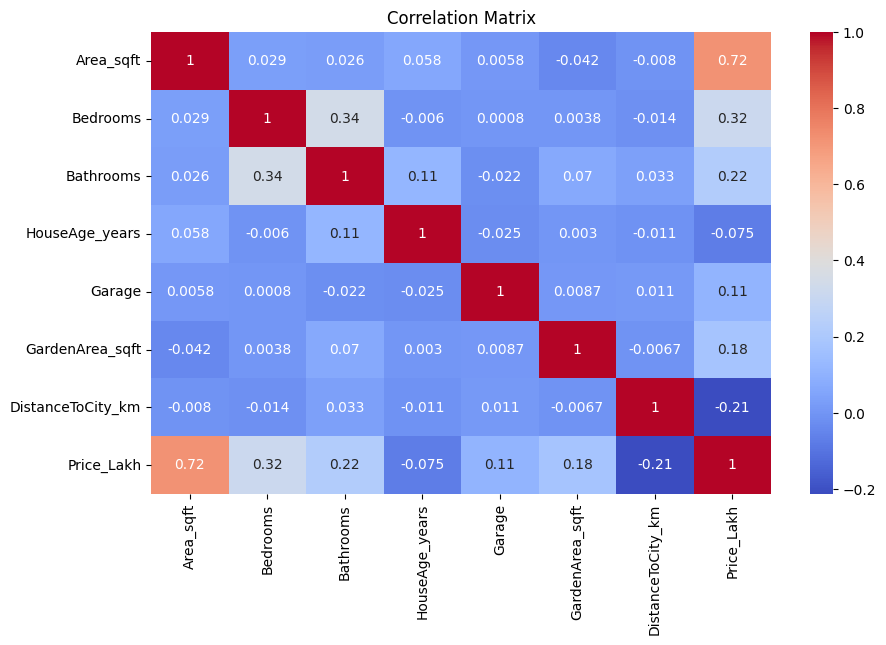

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    house.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

Features with high correlation have strong influence on house price.

In [ ]:
X = house[['Area_sqft']]
y = house['Price_Lakh']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
baseline_pred = baseline_model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, baseline_pred)

mae = mean_absolute_error(
    y_test,
    baseline_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

print("R² =", r2)
print("MAE =", mae)
print("RMSE =", rmse)

R² = 0.425772168094378
MAE = 68.82855527657006
RMSE = 89.16558272898737


In [ ]:
house_encoded = pd.get_dummies(
    house,
    columns=['Location'],
    drop_first=True
)

In [ ]:
X = house_encoded.drop(
    'Price_Lakh',
    axis=1
)

y = house_encoded['Price_Lakh']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X.columns)

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'HouseAge_years', 'Garage',
       'GardenArea_sqft', 'DistanceToCity_km', 'Location_Dhaka',
       'Location_Rajshahi', 'Location_Sylhet'],
      dtype='object')


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, pred)

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print("R² =", r2)
print("MAE =", mae)
print("RMSE =", rmse)

R² = 0.9273115839527751
MAE = 24.24670925512998
RMSE = 31.7239849882381


The baseline model explained approximately 43% of the variation in house prices, whereas the improved model explained approximately 93%, indicating a substantial improvement.



The improved model typically predicts house prices within about ±32 lakh of the actual value.

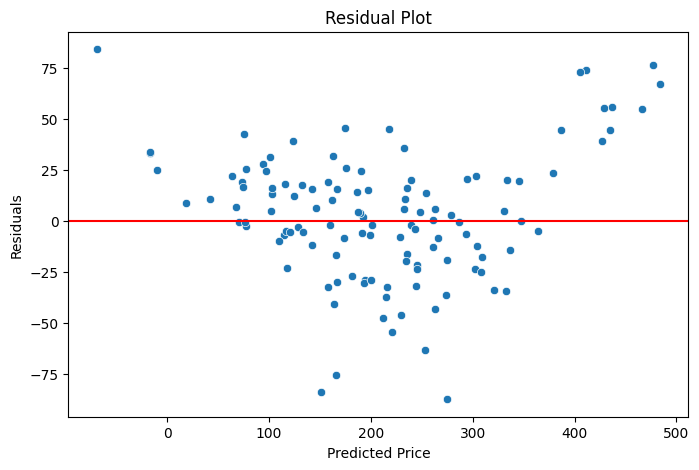

In [ ]:
residuals = y_test - pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")
plt.show()

Random scatter around zero means the model perform well.

In [ ]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_table.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
7,Location_Dhaka,93.109526
4,Garage,15.234205
1,Bedrooms,13.989442
2,Bathrooms,8.538343
0,Area_sqft,0.067259
5,GardenArea_sqft,0.027634
3,HouseAge_years,-1.150778
6,DistanceToCity_km,-2.295208
9,Location_Sylhet,-15.824889
8,Location_Rajshahi,-46.933180


Coefficient Interpretation

The coefficient table shows how each feature affects house prices while keeping other features constant.

1. Location_Dhaka (93.11)
Houses in Dhaka are approximately 93.11 lakh more expensive than the reference city.

2. Garage (15.23)
Having a garage increases house price by about 15.23 lakh.

3. Bedrooms (13.99)
Each additional bedroom increases price by about 13.99 lakh.

4. Bathrooms (8.54)
Each additional bathroom increases price by about 8.54 lakh.

5. Area_sqft (0.067)
Each extra square foot increases price by about 0.067 lakh.

6. GardenArea_sqft (0.028)
A larger garden area slightly increases house price.

7. HouseAge_years (-1.15)
Every additional year of house age decreases price by about 1.15 lakh.

8. DistanceToCity_km (-2.30)
Every extra kilometer away from the city center decreases price by about 2.30 lakh.

9. Location_Sylhet (-15.82)
Houses in Sylhet are approximately 15.82 lakh cheaper than the reference city.

10. Location_Rajshahi (-46.93)
Houses in Rajshahi are approximately 46.93 lakh cheaper than the reference city.

Top 3 Factors Affecting Price:

1. Location (Dhaka) → +93.11 lakh
2. Garage → +15.23 lakh
3. Bedrooms → +13.99 lakh

Business Conclusion:

Location is the most important factor affecting house prices. Houses in Dhaka command significantly higher prices. Properties with garages, more bedrooms, and more bathrooms tend to be more expensive. Older houses and houses farther from the city center tend to have lower prices.

In [ ]:
examples = pd.DataFrame({
'Area_sqft':[1500,2200,3000],
'Bedrooms':[3,4,5],
'Bathrooms':[2,3,4],
'HouseAge_years':[10,5,2],
'Garage':[1,1,1],
'GardenArea_sqft':[100,200,300],
'DistanceToCity_km':[5,8,3],
'Location_Dhaka':[1,0,1], # For the second example, all location dummies are 0 for 'Chittagong'
'Location_Rajshahi':[0,0,0], # Added this missing feature
'Location_Sylhet':[0,0,0]
})

model.predict(examples)

array([239.892943  , 218.02443368, 405.16102177])

Final Conclusion

1. Data cleaned by handling missing values.

2. HouseID removed because it is not useful for prediction.

3. EDA showed that larger houses generally have higher prices.

4. Location significantly affects house prices.

5. Multiple Linear Regression performed better than Simple Linear Regression.

6. Area, Bedrooms and Location are the most important factors affecting house prices.

7. The improved model achieved an R² score of 0.93, which means it can explain about 93% of the variation in house prices.

8. The model can estimate house prices automatically for new listings and help real-estate agents make more consistent and data-driven pricing decisions.

9. Based on the coefficient analysis, houses in Dhaka have the highest prices, while older houses and houses located farther from the city center tend to have lower prices.

10. Overall, the developed Property Price Estimator is accurate, reliable, and suitable for predicting house prices using machine learning techniques.